<a href="https://colab.research.google.com/github/Limsungrae/Hongong/blob/main/%ED%98%BC%EA%B3%B5%EB%A8%B8%EC%8B%A06_3%EC%A3%BC%EC%84%B1%EB%B6%84_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 ### PCA 클래스

In [1]:
!wget https://bit.ly/fruits_300_data -O fruits_300.npy

--2026-04-28 01:37:37--  https://bit.ly/fruits_300_data
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy [following]
--2026-04-28 01:37:37--  https://github.com/rickiepark/hg-mldl/raw/master/fruits_300.npy
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy [following]
--2026-04-28 01:37:38--  https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fruits_300.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... conne

In [5]:
import numpy as np

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100*100)

#### pca 는 2차원 데이터만 입력이 가능하다.
#### 이미지 데이터는 3차원이므로 변환이 필요하다
#### reshape 으로 각 이미지를 1차원 백터로 변환

#### pca 는 2차원 데이터만 처리할 수 있으므로 이미지 데이터를 reshape 하여 형태로 변환하여한다.

### 차원축소
##### 데이터의 정보를 최대한 유지하면서 변수 개수를 줄이는 방법
##### 비지도학습, 시각화할때 자주 사용 머신러닝 성능 개선에 도움

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50) # 50차원으로 주성분축소
pca.fit(fruits_2d)

PCA(n_components=50)

In [7]:
# pca 에서 만들어진 주성분 벡터 의 개수와 형태 출력

print(pca.components_.shape)

(50, 10000)


In [10]:
# 과일 이미지 데이터를 격자 형태로 시각화하는 함수
import matplotlib.pyplot as plt

def draw_fruits(arr, ratio=1):
    """
    주어진 이미지 배열을 격자 형태로 시각화합니다.

    Args:
        arr (numpy.ndarray): 시각화할 이미지 데이터 배열. 각 이미지는 (100, 100) 형태로 예상됩니다.
        ratio (int, optional): 그림의 크기 조정 비율. Defaults to 1.
    """
    n = len(arr)    # 이미지 배열의 총 개수 (그릴 이미지의 수)

    # 한 줄에 10개씩 이미지를 그리기 위해 전체 행 개수를 계산합니다.
    rows = int(np.ceil(n/10))
    # 행이 1개인 경우 열 개수는 이미지 개수와 같고, 그렇지 않으면 10개로 고정합니다.
    cols = n if rows < 2 else 10

    # 서브플롯을 생성합니다. figsize는 각 이미지의 크기와 전체 격자 크기를 고려하여 설정됩니다.
    fig, axs = plt.subplots(rows, cols,
                            figsize=(cols*ratio, rows*ratio), squeeze=False)

    # 각 서브플롯에 이미지를 그립니다.
    for i in range(rows):
        for j in range(cols):
            # 현재 이미지 인덱스가 전체 이미지 개수(n)를 초과하지 않는 경우에만 그립니다.
            if i*10 + j < n:
                # 이미지를 흑백으로 표시하고, 축을 숨깁니다.
                axs[i, j].imshow(arr[i*10 + j], cmap='gray_r')
            axs[i, j].axis('off') # 모든 축을 비활성화합니다.

    plt.show() # 그림을 화면에 표시합니다.

#### 자주 쓰는 cmap
gray - 흑백(일반) 검정 - 낮은값 흰색 - 높은값 000 검정 fff 흰색 0 검정 255 흰색
#### gray_r - 흑백을 반대로(reverse) 흰색-낮은값, 검정-높은값
#### viridis(기본컬러) -기본 컬러 파랑-> 초록-> 노랑(값이 커질수록 밝아짐)
#### jet 무지개 색 (잘 안씀)
쓰는 이유
숫자 데이터를 눈으로 보기 쉽게 색으로 표현하기 위해서
픽셀값 (0~ 255) 0 어둡게 255 밝게



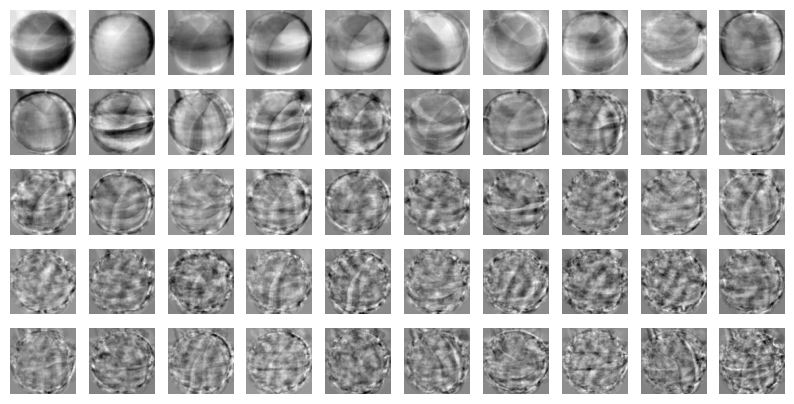

In [9]:
# PCA 주성분을 이미지 형태로 시각화
draw_fruits(pca.components_.reshape(-1, 100, 100))

In [12]:
print(fruits_2d.shape)
# 300개 이미지, 각 이미지를 1차원 형태로 10000 으로 펼친 상태
# 원래 형태 = 300,300,100

(300, 10000)


In [13]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)
# 학습된 주성분 기준으로 데이터 변환 완료

(300, 50)


#### 원본 데이터 재구성
#### 차원 축소된 데이터를 다시 원래 차원으로 복원(근사복원)
#### reshape 과 모양비교 - 모양만 변경
#### inverse_transform > 값 자체 복원 (차원은 원래대로 돌아가지만 값은 완전 같지 않다)
#### 완전 복원 안되는 이유
#### pca 는 일부 정보를 버림

In [14]:
# 차원 축소된 데이터를 다시 원본 차원으로 복원합니다.
# inverse_transform을 사용하여 fruits_pca 데이터를 fruits_2d와 같은 형태로 복원합니다.
fruits_reconstruct = pca.inverse_transform(fruits_pca)
print(fruits_reconstruct.shape)

(300, 10000)


복원된 데이터의 모양은 `fruits_2d`와 동일하지만, PCA 과정에서 정보 손실이 발생했기 때문에 원본 데이터와 완전히 동일하지는 않습니다. 다음으로 복원된 이미지를 시각화하여 원본 이미지와 비교해 봅시다.

원본 이미지:


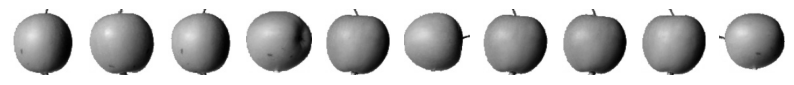

PCA로 복원된 이미지:


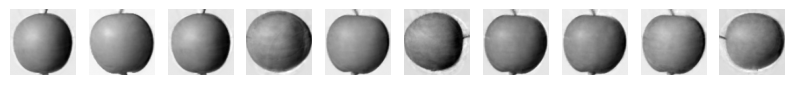

In [15]:
# 복원된 데이터를 원본 이미지 형태로 재구성하여 시각화합니다.
# fruits_reconstruct는 2차원이므로, draw_fruits 함수에 전달하기 위해 3차원 (이미지 개수, 높이, 너비) 형태로 reshape 합니다.

# 원본 데이터
print('원본 이미지:')
draw_fruits(fruits.reshape(-1, 100, 100)[0:10])

# 복원된 데이터
print('PCA로 복원된 이미지:')
draw_fruits(fruits_reconstruct.reshape(-1, 100, 100)[0:10])

In [16]:
print(np.sum(pca.explained_variance_ratio_))

0.9214935597046149


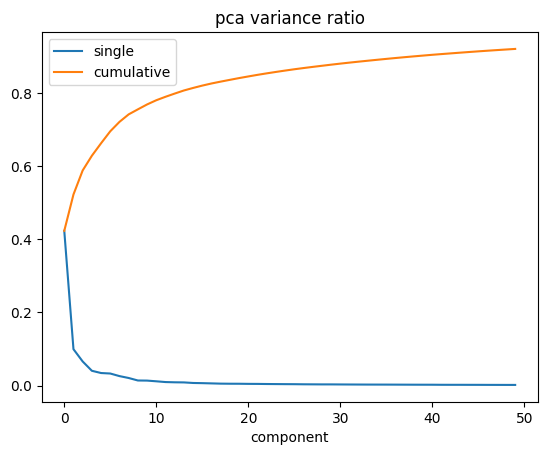

In [19]:
plt.plot(pca.explained_variance_ratio_)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('pca variance ratio')
plt.xlabel('component')
plt.legend(['single', 'cumulative'])
plt.show()

#### 다른 알고리즘과 함께 사용하기

In [20]:
# 로지스틱 회귀 모델
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
# 3개의 클래스 (0,1,2) 를 가진 정답 데이터 만들기
target = np.array([0]*100 + [1]*100 + [2]*100)

In [21]:
print(target.shape)
#

(300,)


In [23]:
# 교차 검증
from sklearn.model_selection import cross_validate
scores = cross_validate(lr, fruits_2d, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))
#

0.9966666666666667
1.2351147651672363


In [24]:
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [25]:
print(pca.n_components_)

2


In [27]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [26]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.9966666666666667
0.014020729064941406


In [28]:
pca = PCA(n_components=0.5)
pca.fit(fruits_2d)

PCA(n_components=0.5)

In [29]:
fruits_pca = pca.transform(fruits_2d)
print(fruits_pca.shape)

(300, 2)


In [30]:
scores = cross_validate(lr, fruits_pca, target)
print(np.mean(scores['test_score']))
print(np.mean(scores['fit_time']))

0.99
0.03473110198974609


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [31]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42)
km.fit(fruits_pca)

KMeans(n_clusters=3, random_state=42)

In [32]:
print(np.unique(km.labels_, return_counts=True))

(array([0, 1, 2], dtype=int32), array([110,  99,  91]))


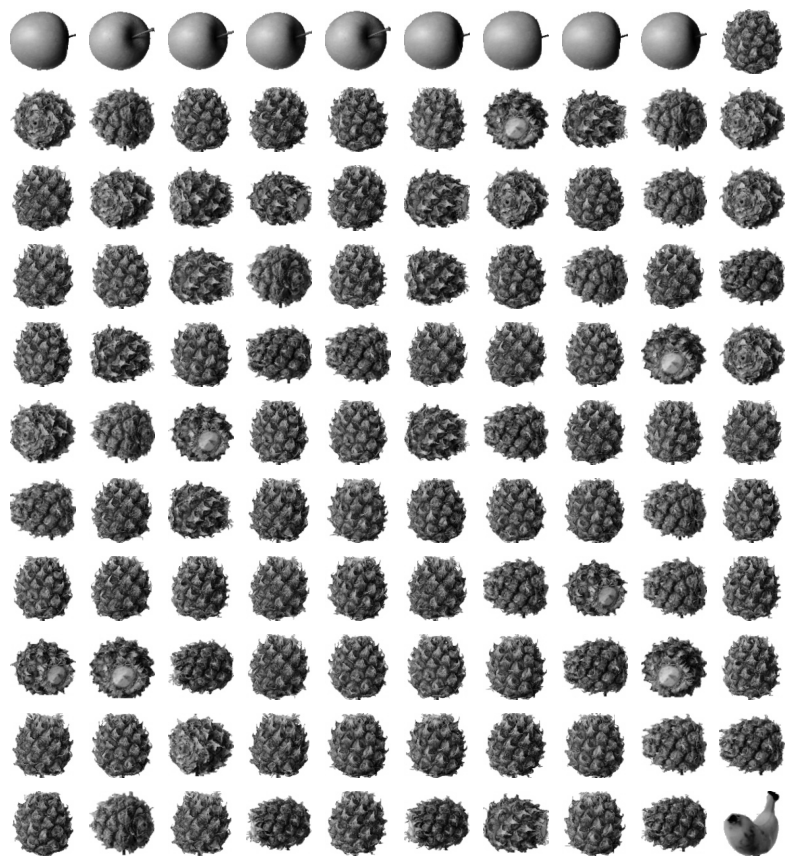

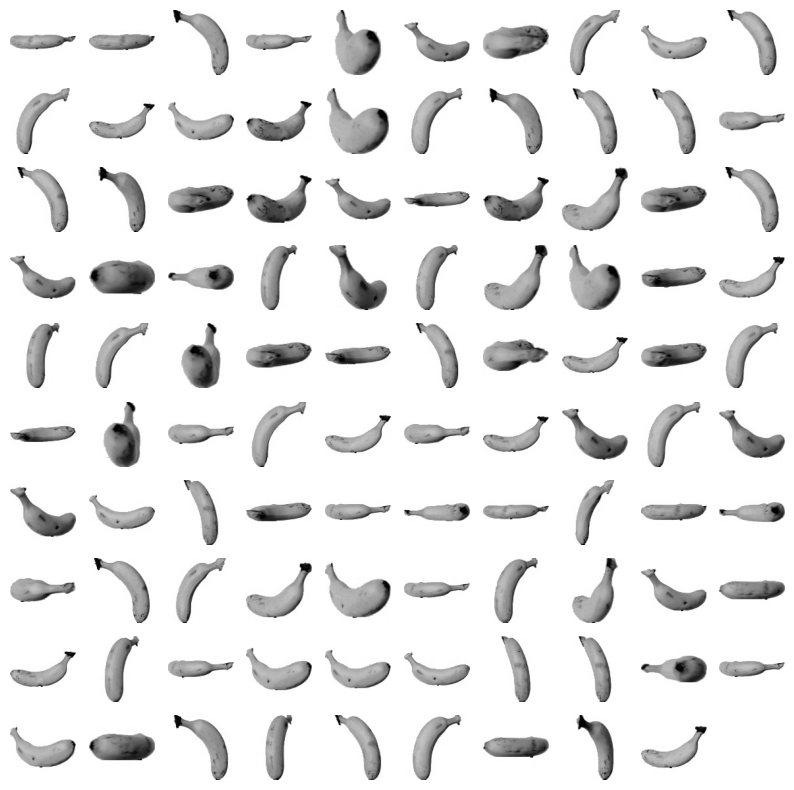

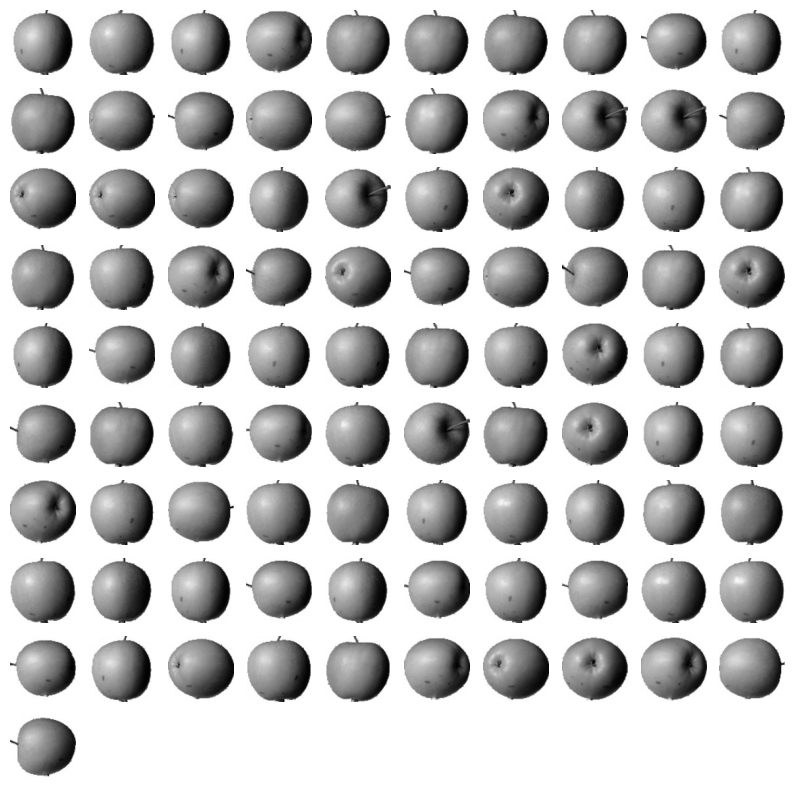

In [33]:
for label in range(0, 3):
    draw_fruits(fruits[km.labels_ == label])
    print("\n")

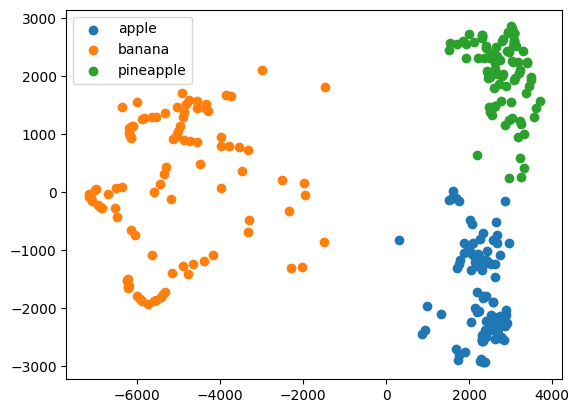

In [34]:
for label in range(0, 3):
    data = fruits_pca[km.labels_ == label]
    plt.scatter(data[:,0], data[:,1])
plt.legend(['apple', 'banana', 'pineapple'])
plt.show()

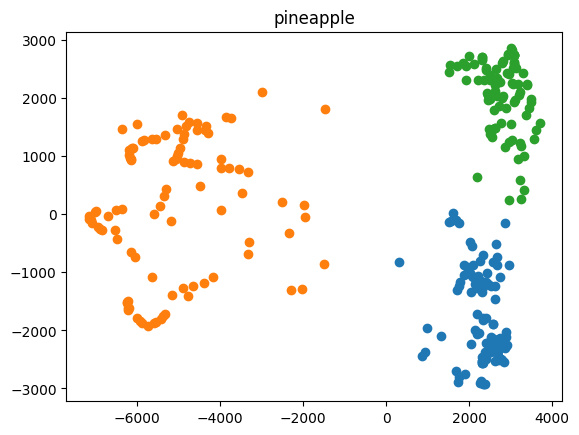

In [35]:
for lable ,name in zip([0,1,2],['apple','banana','pineapple']):
  data = fruits_pca[km.labels_ == lable]
  plt.scatter(data[:,0], data[:,1])
  plt.title(name)
plt.show()